In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gps.gps_receiver import GpsReceiver

In [14]:
fs = 4.092e6

# samples = np.fromfile("data/gpssim.ci16", dtype=np.int8, count=int(fs*2*10))
samples = np.fromfile("data/gpssim.ci16", dtype=np.int8)
samples = samples[::2].astype(np.complex64) + 1j * samples[1::2].astype(np.complex64)
print(samples.dtype, len(samples))

complex64 245110800


In [15]:
rx = GpsReceiver(fs, channels=12, debug=True)

i = 0

while i < len(samples):
    d = np.random.randint(256, 65536)
    # d = 16000

    new_samples = samples[i:i+d]
    rx.update(new_samples)

    i += d

[Acquisition] Searching 2.00ms period, N=8192
[Acquisition] 499.5Hz frequency bins
[Acquisition] SV: 3, Doppler shift: -999.02Hz, Code sample phase: 2059/4092, SNR: 12.5
[Acquisition] SV: 4, Doppler shift: 2997.07Hz, Code sample phase: 3753/4092, SNR: 8.9
[Acquisition] SV: 9, Doppler shift: 3496.58Hz, Code sample phase: 1208/4092, SNR: 9.5
[Acquisition] SV: 16, Doppler shift: 2497.56Hz, Code sample phase: 2591/4092, SNR: 17.0
[Acquisition] SV: 26, Doppler shift: 0.00Hz, Code sample phase: 1866/4092, SNR: 19.6
[Acquisition] SV: 27, Doppler shift: 3496.58Hz, Code sample phase: 2376/4092, SNR: 7.3
[Acquisition] SV: 28, Doppler shift: -1998.05Hz, Code sample phase: 1132/4092, SNR: 14.9
[Acquisition] SV: 29, Doppler shift: -499.51Hz, Code sample phase: 3336/4092, SNR: 7.4
[Acquisition] SV: 31, Doppler shift: -999.02Hz, Code sample phase: 3774/4092, SNR: 12.2
[Acquisition] SV: 32, Doppler shift: -3496.58Hz, Code sample phase: 3066/4092, SNR: 7.3
[Acquisition] Fine freq: -1061.7 Hz, +-62.4 Hz

In [13]:
for i in range(np.sum(rx.acquired > 0)):
    iq = rx.channels[i].decoder.sample_buffer
    iq = np.array(iq, dtype=np.complex64)

    iq.tofile(f"data/downsampled{i}.cf64")

In [18]:
len(rx.channels[1].decoder.sample_buffer)

59900

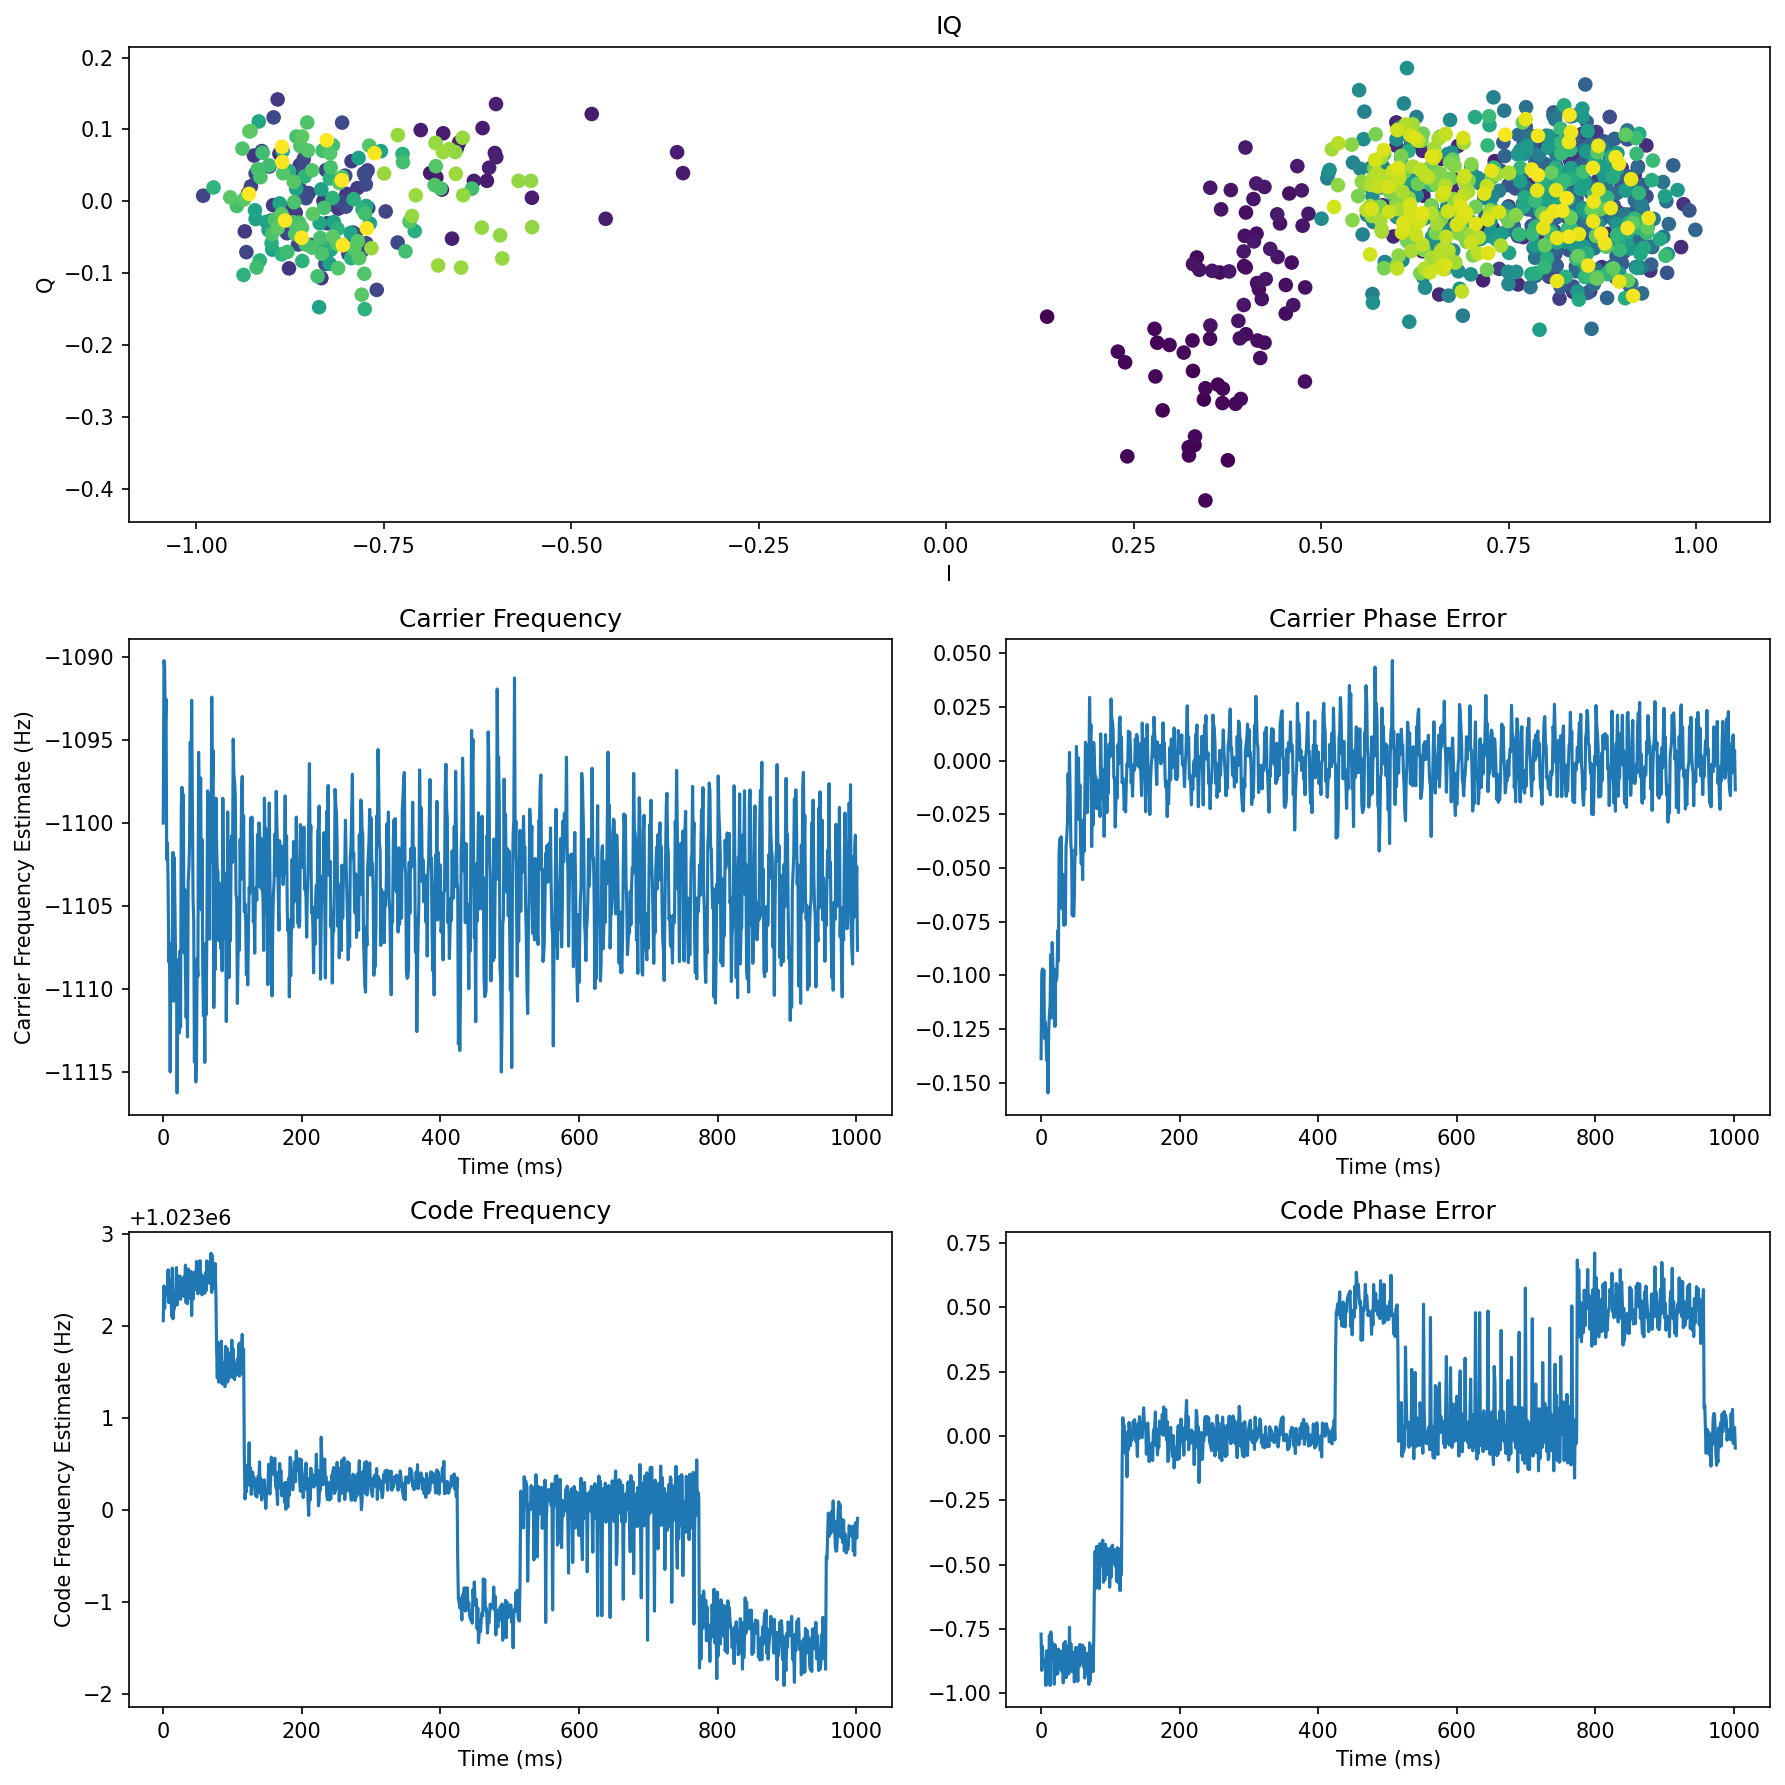

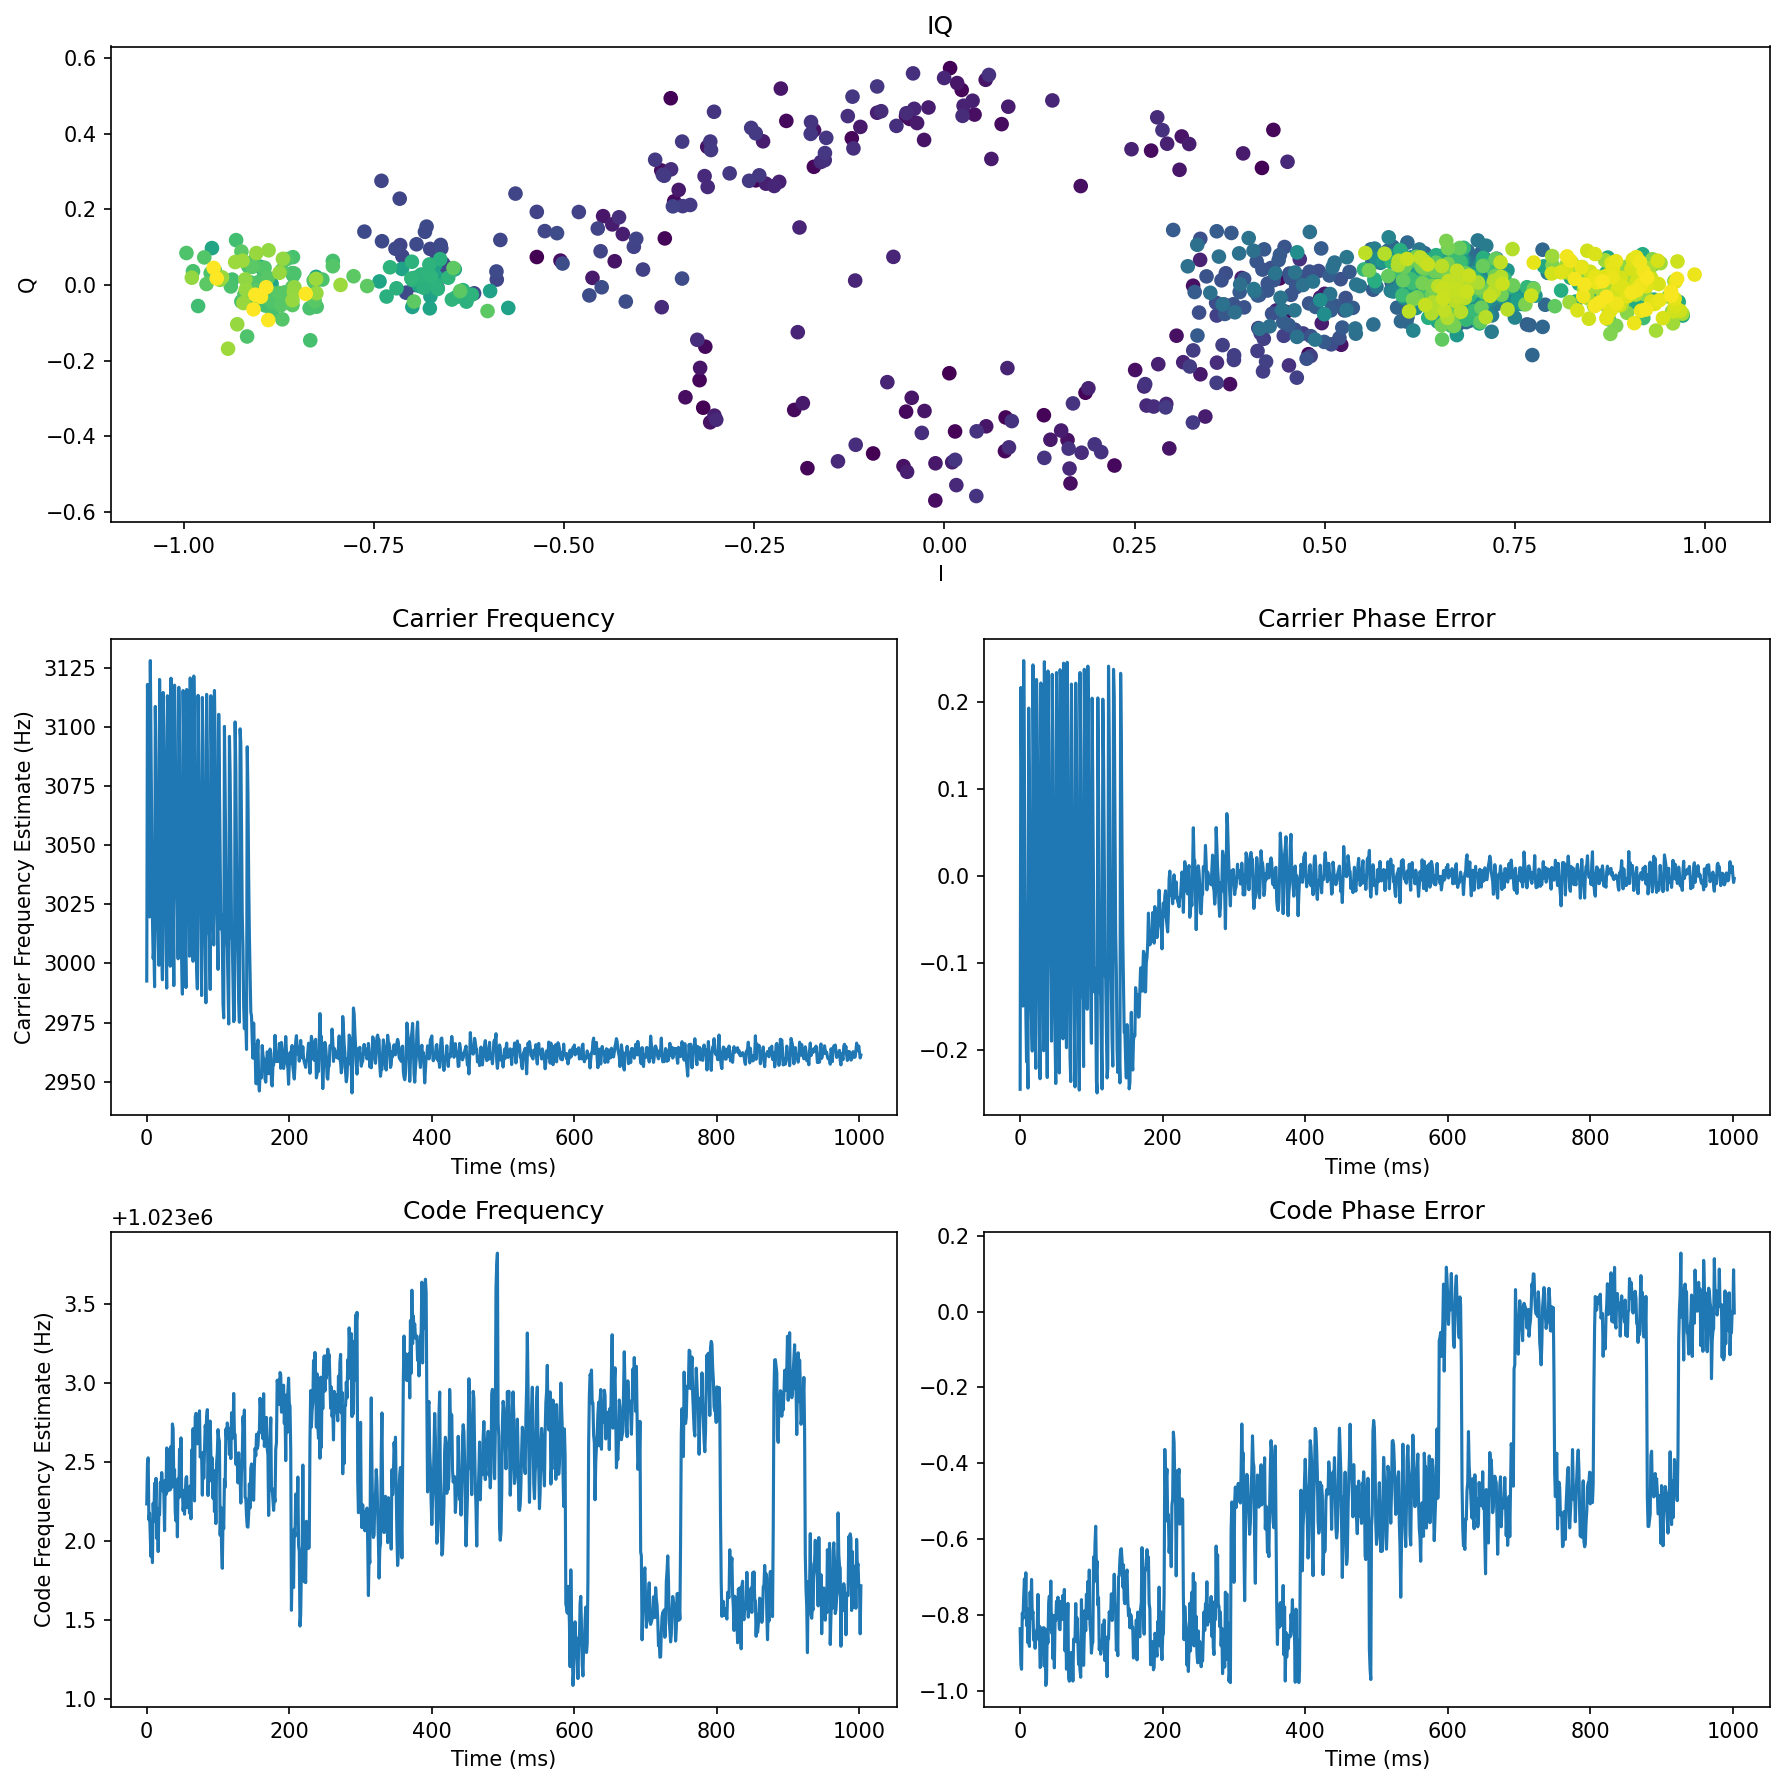

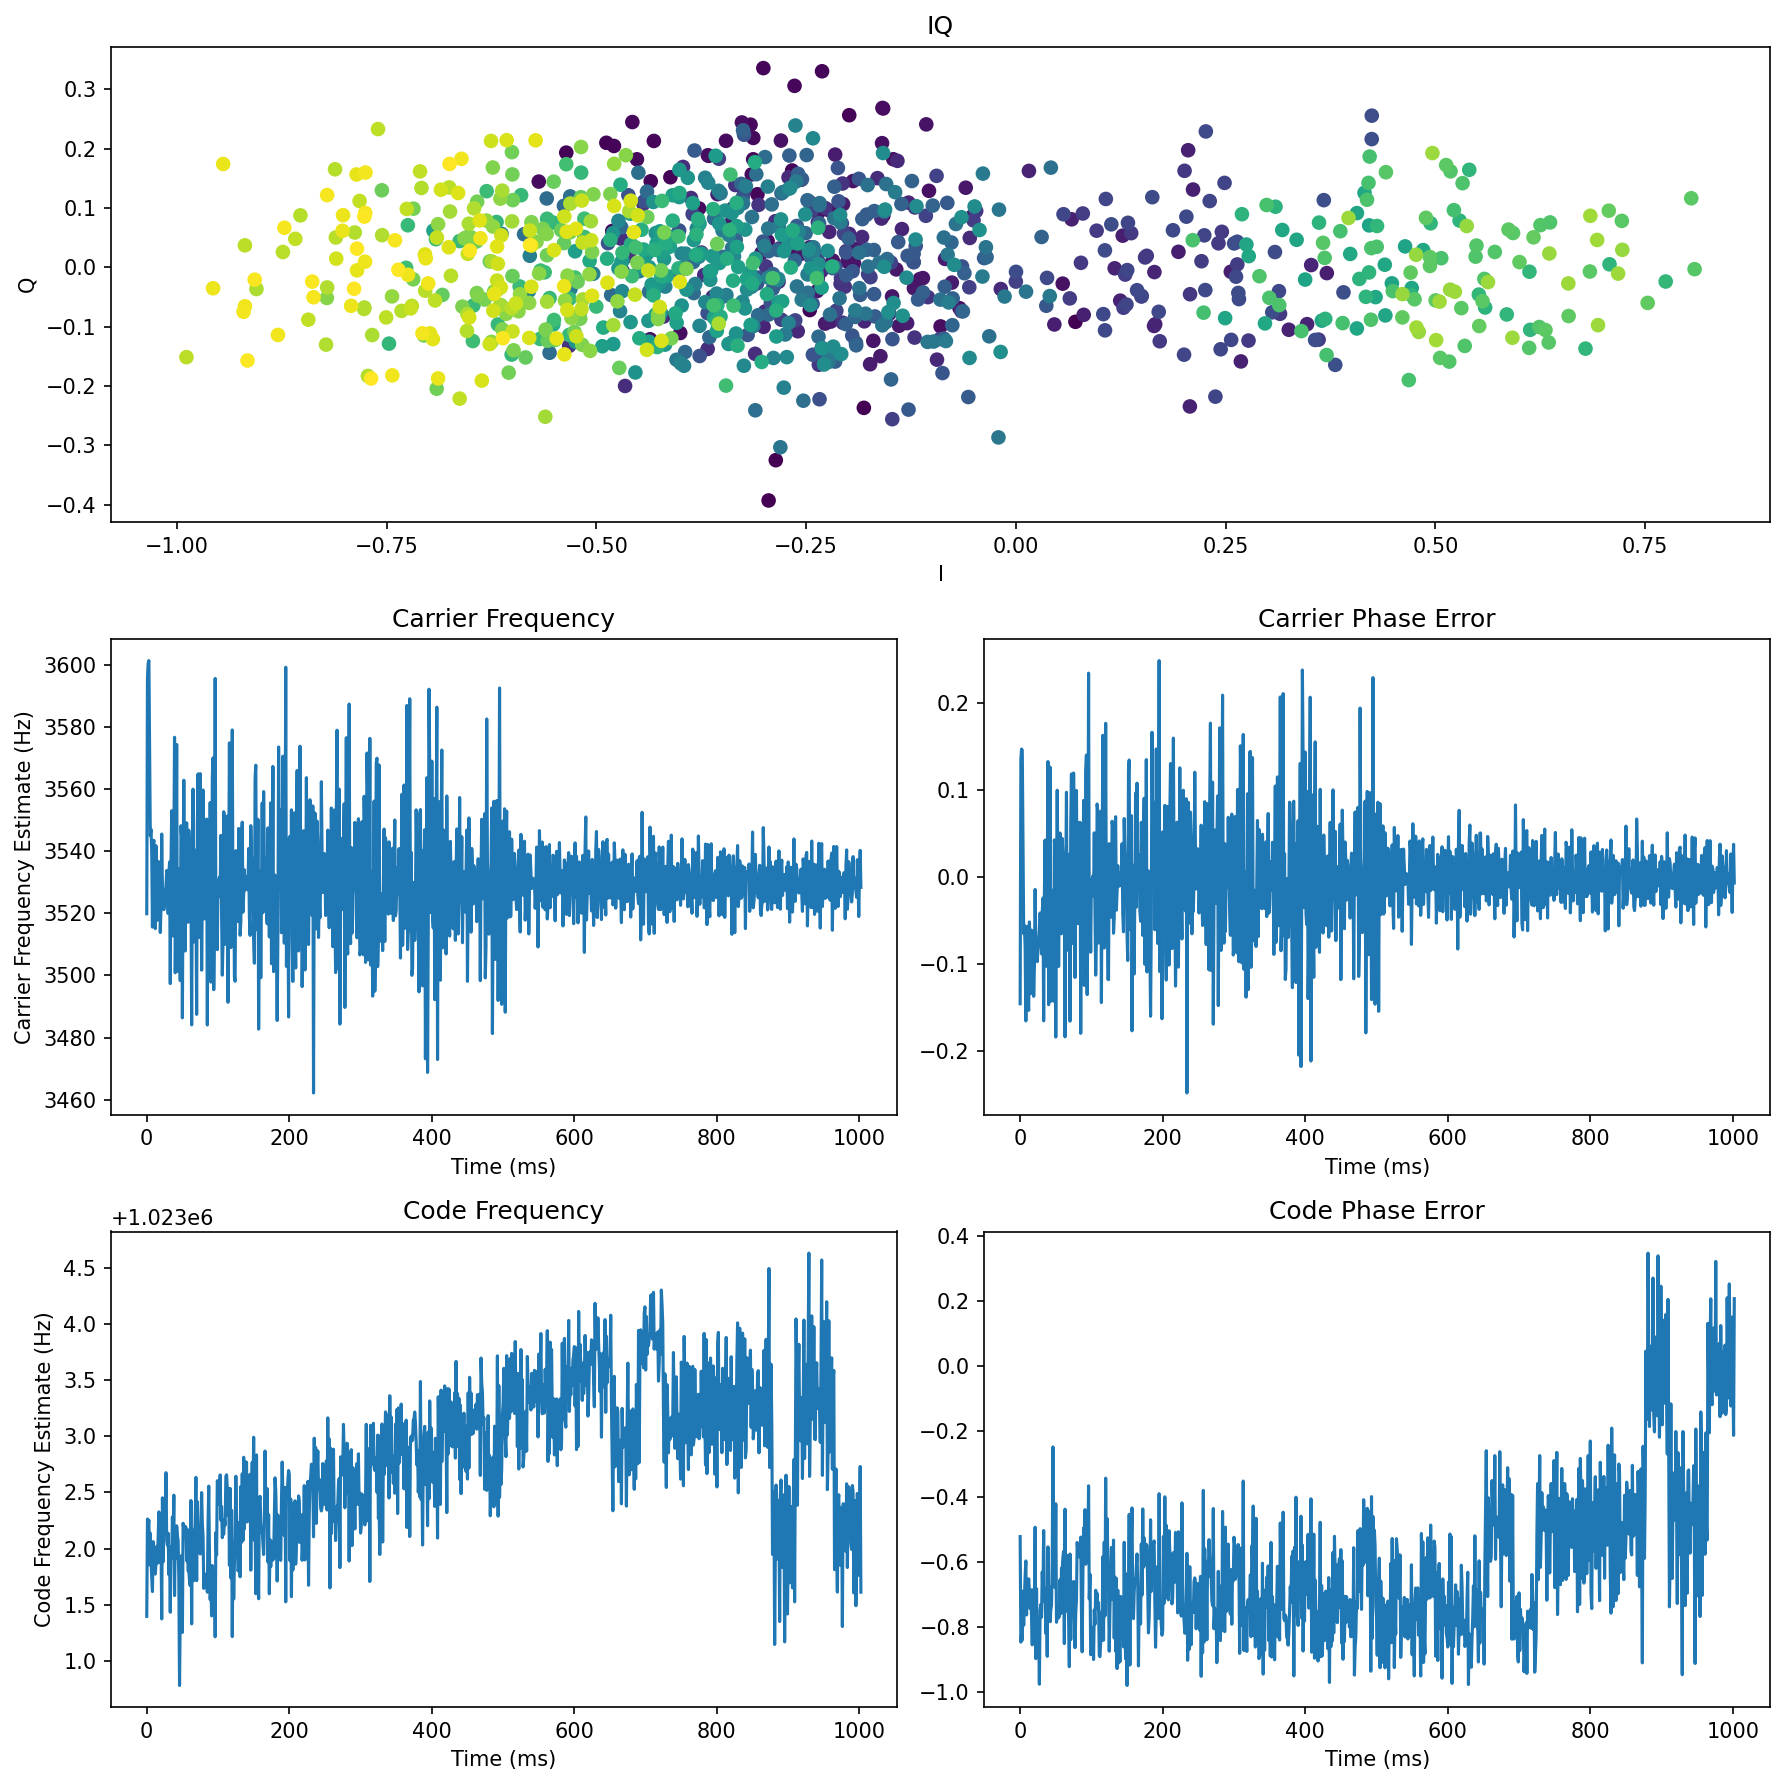

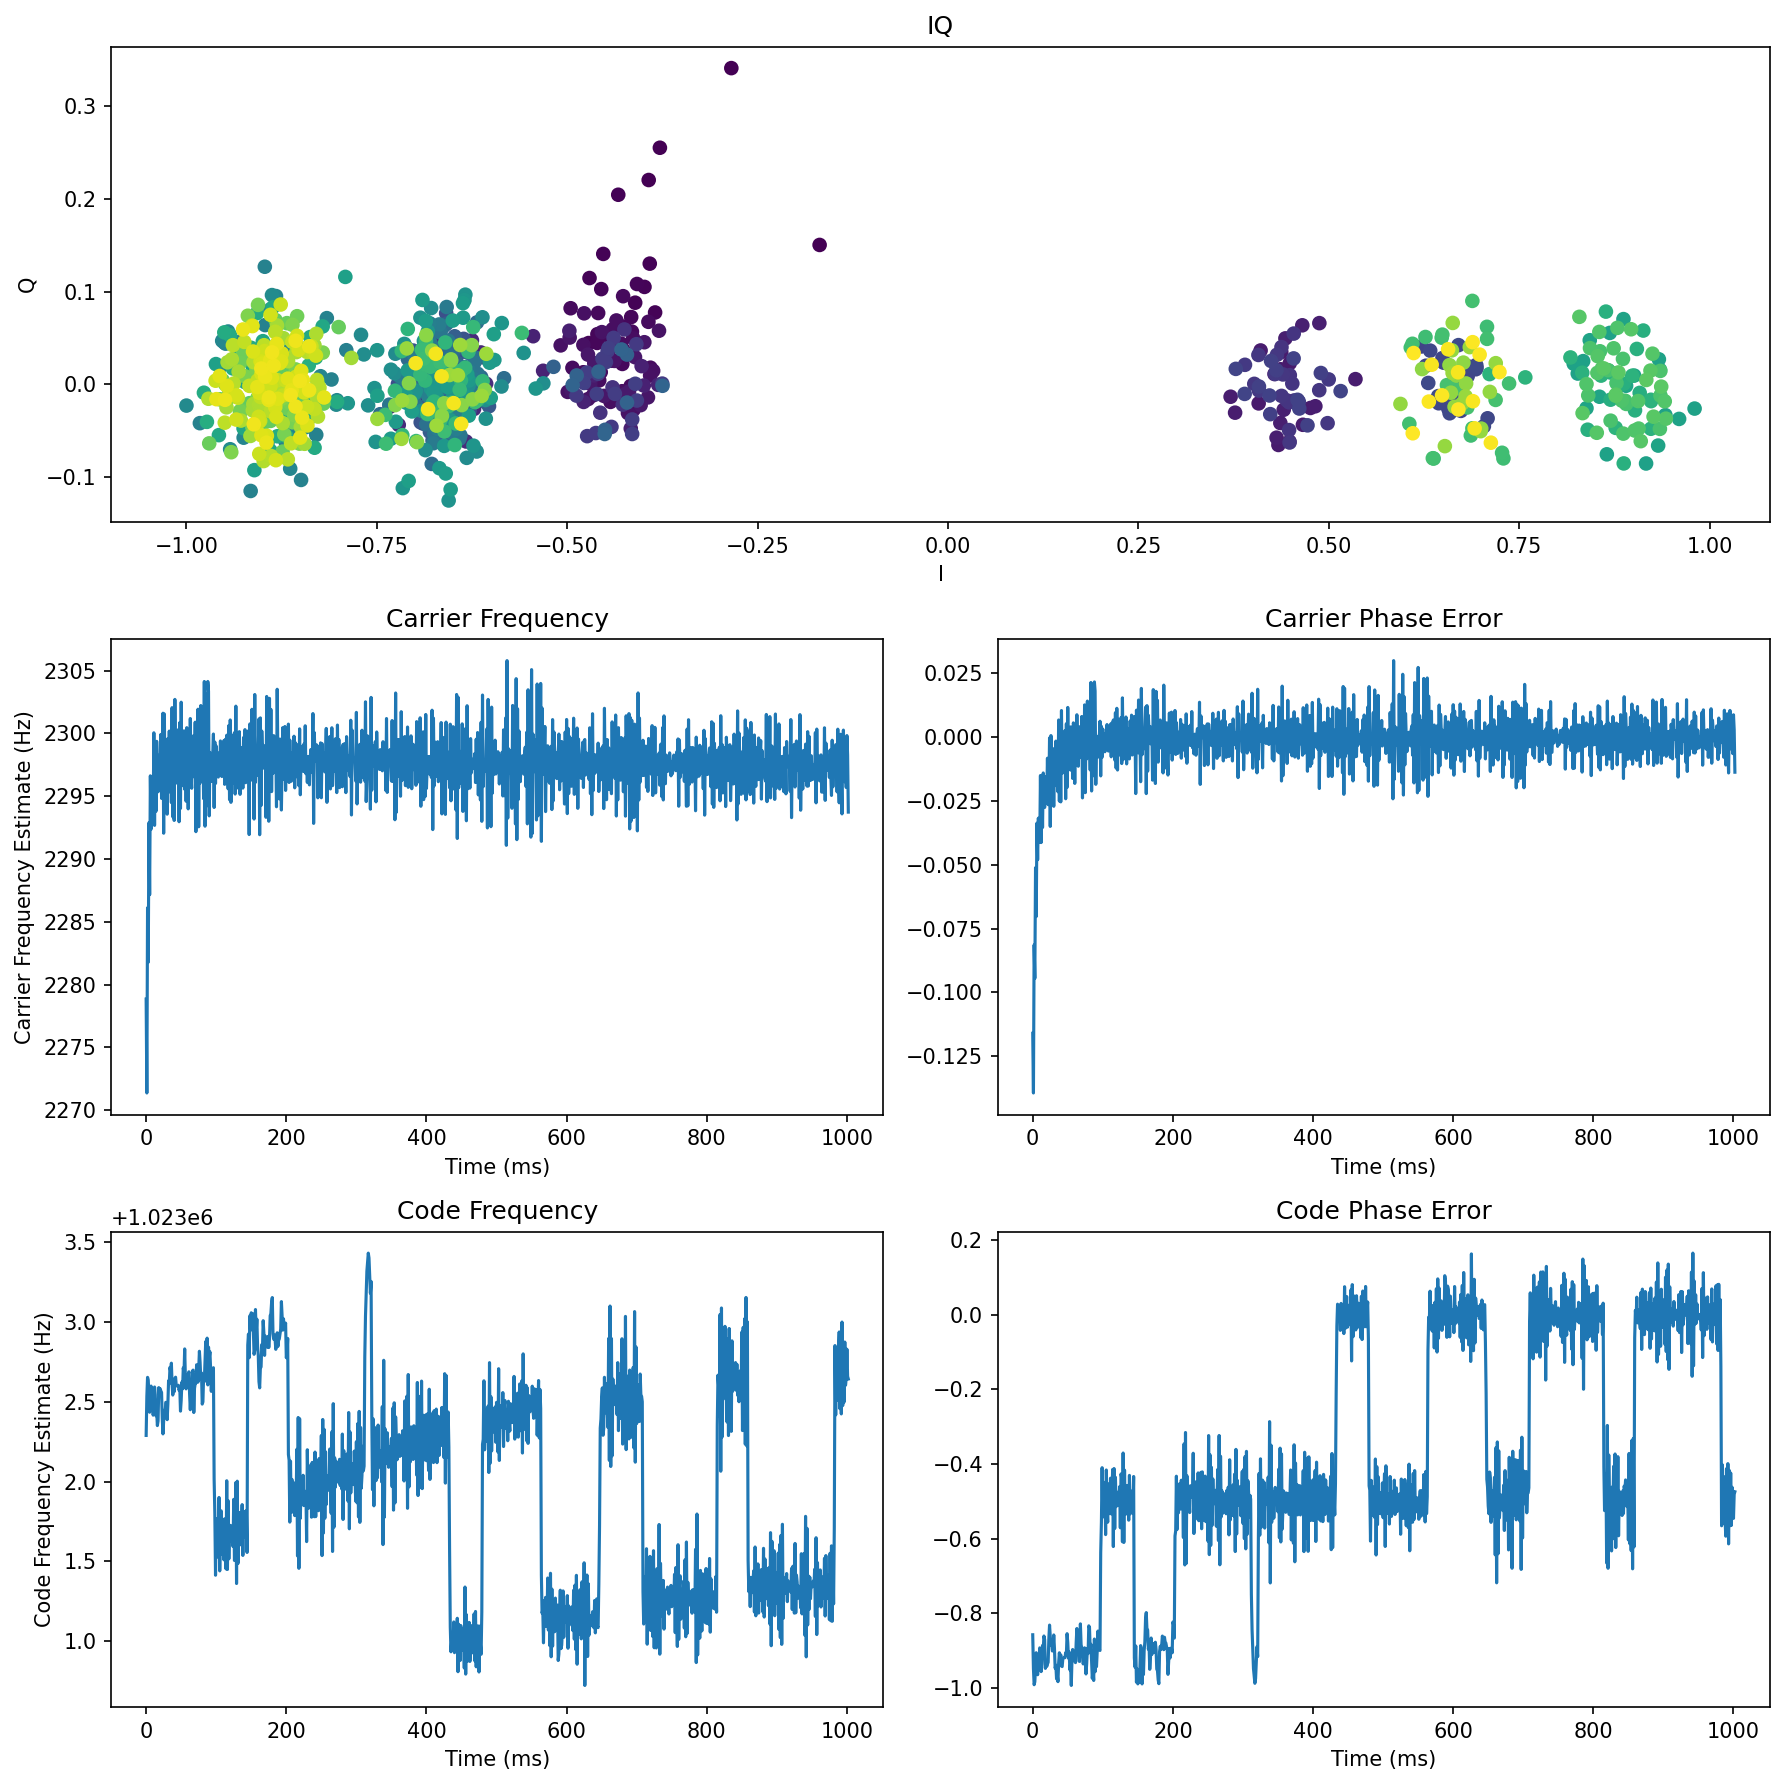

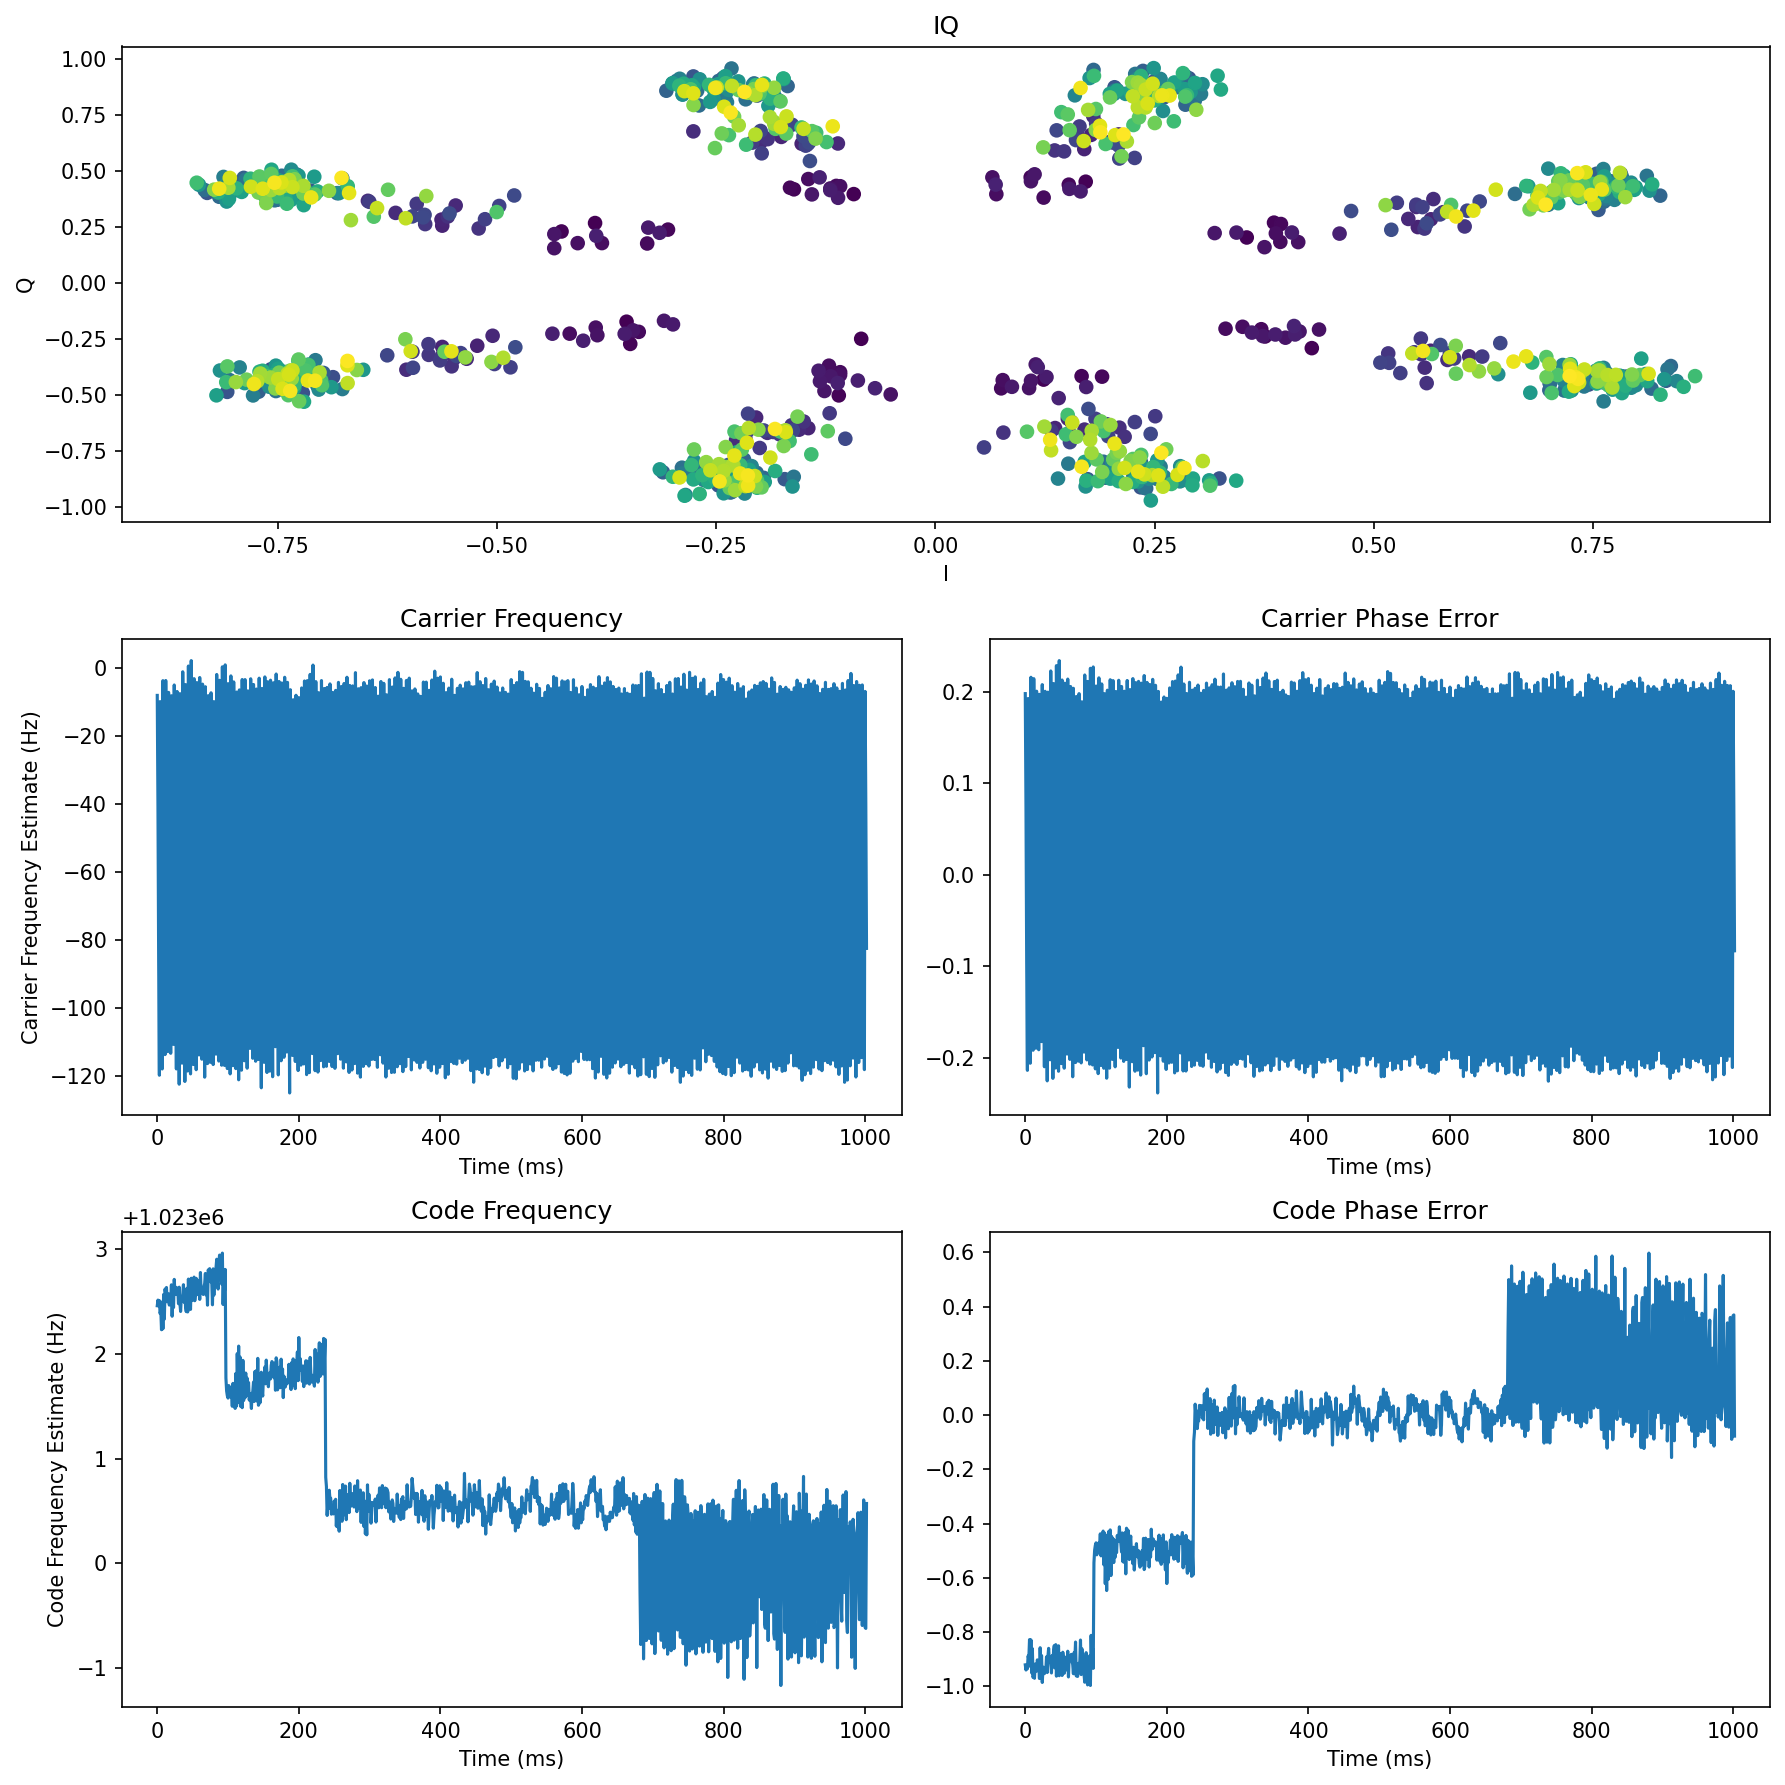

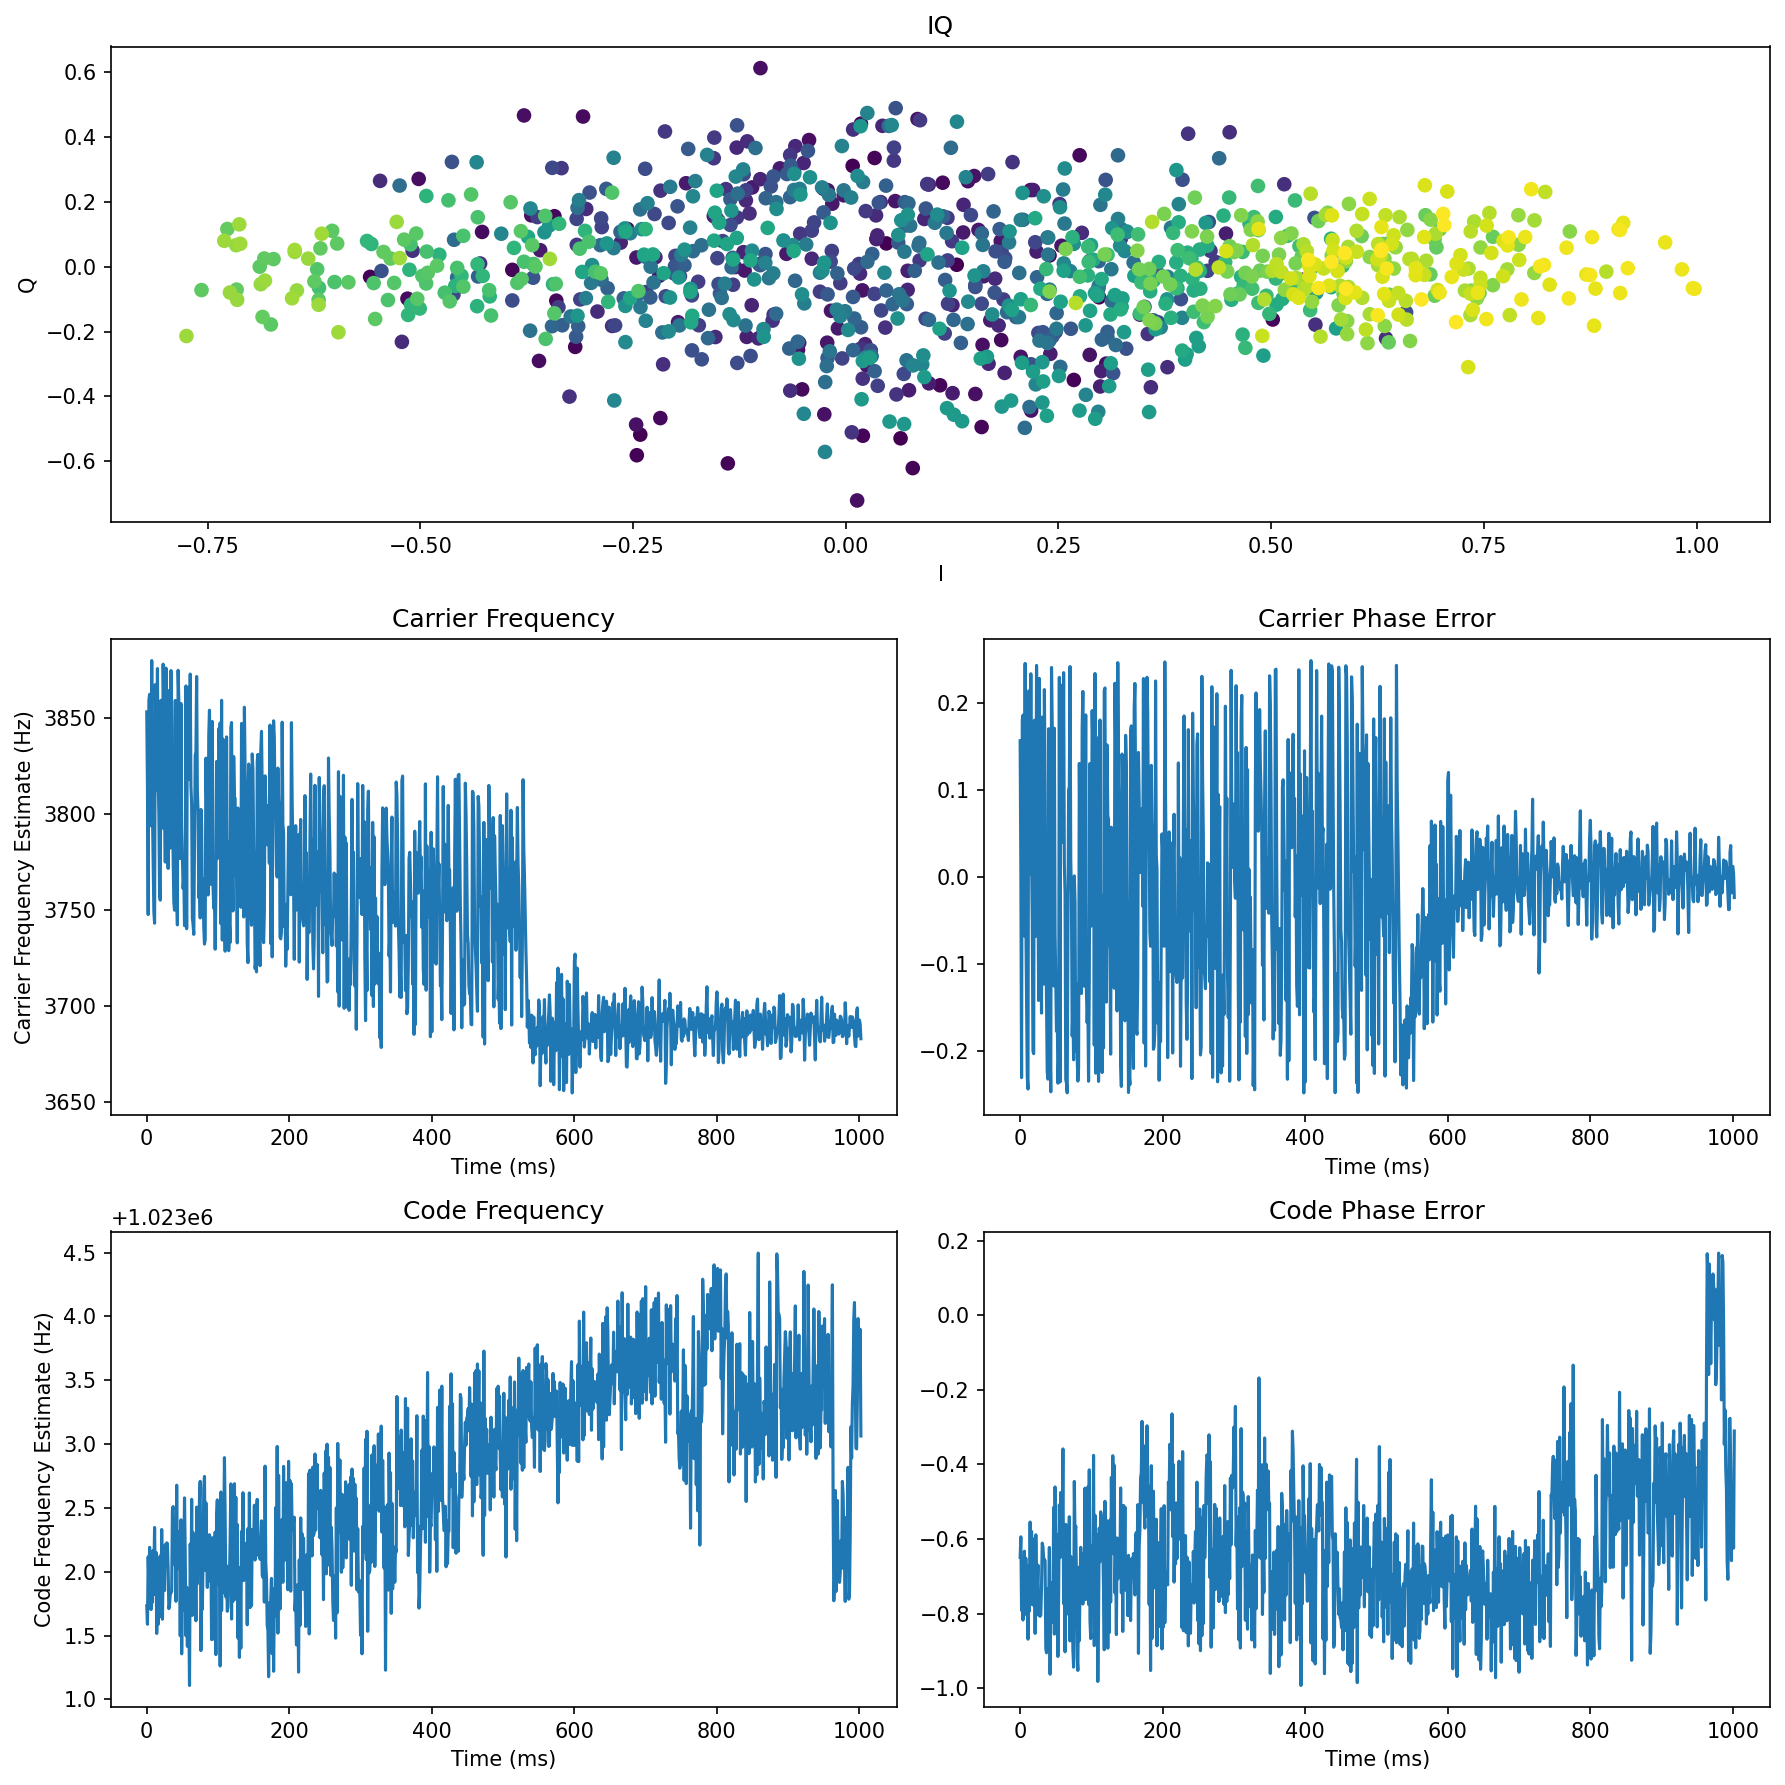

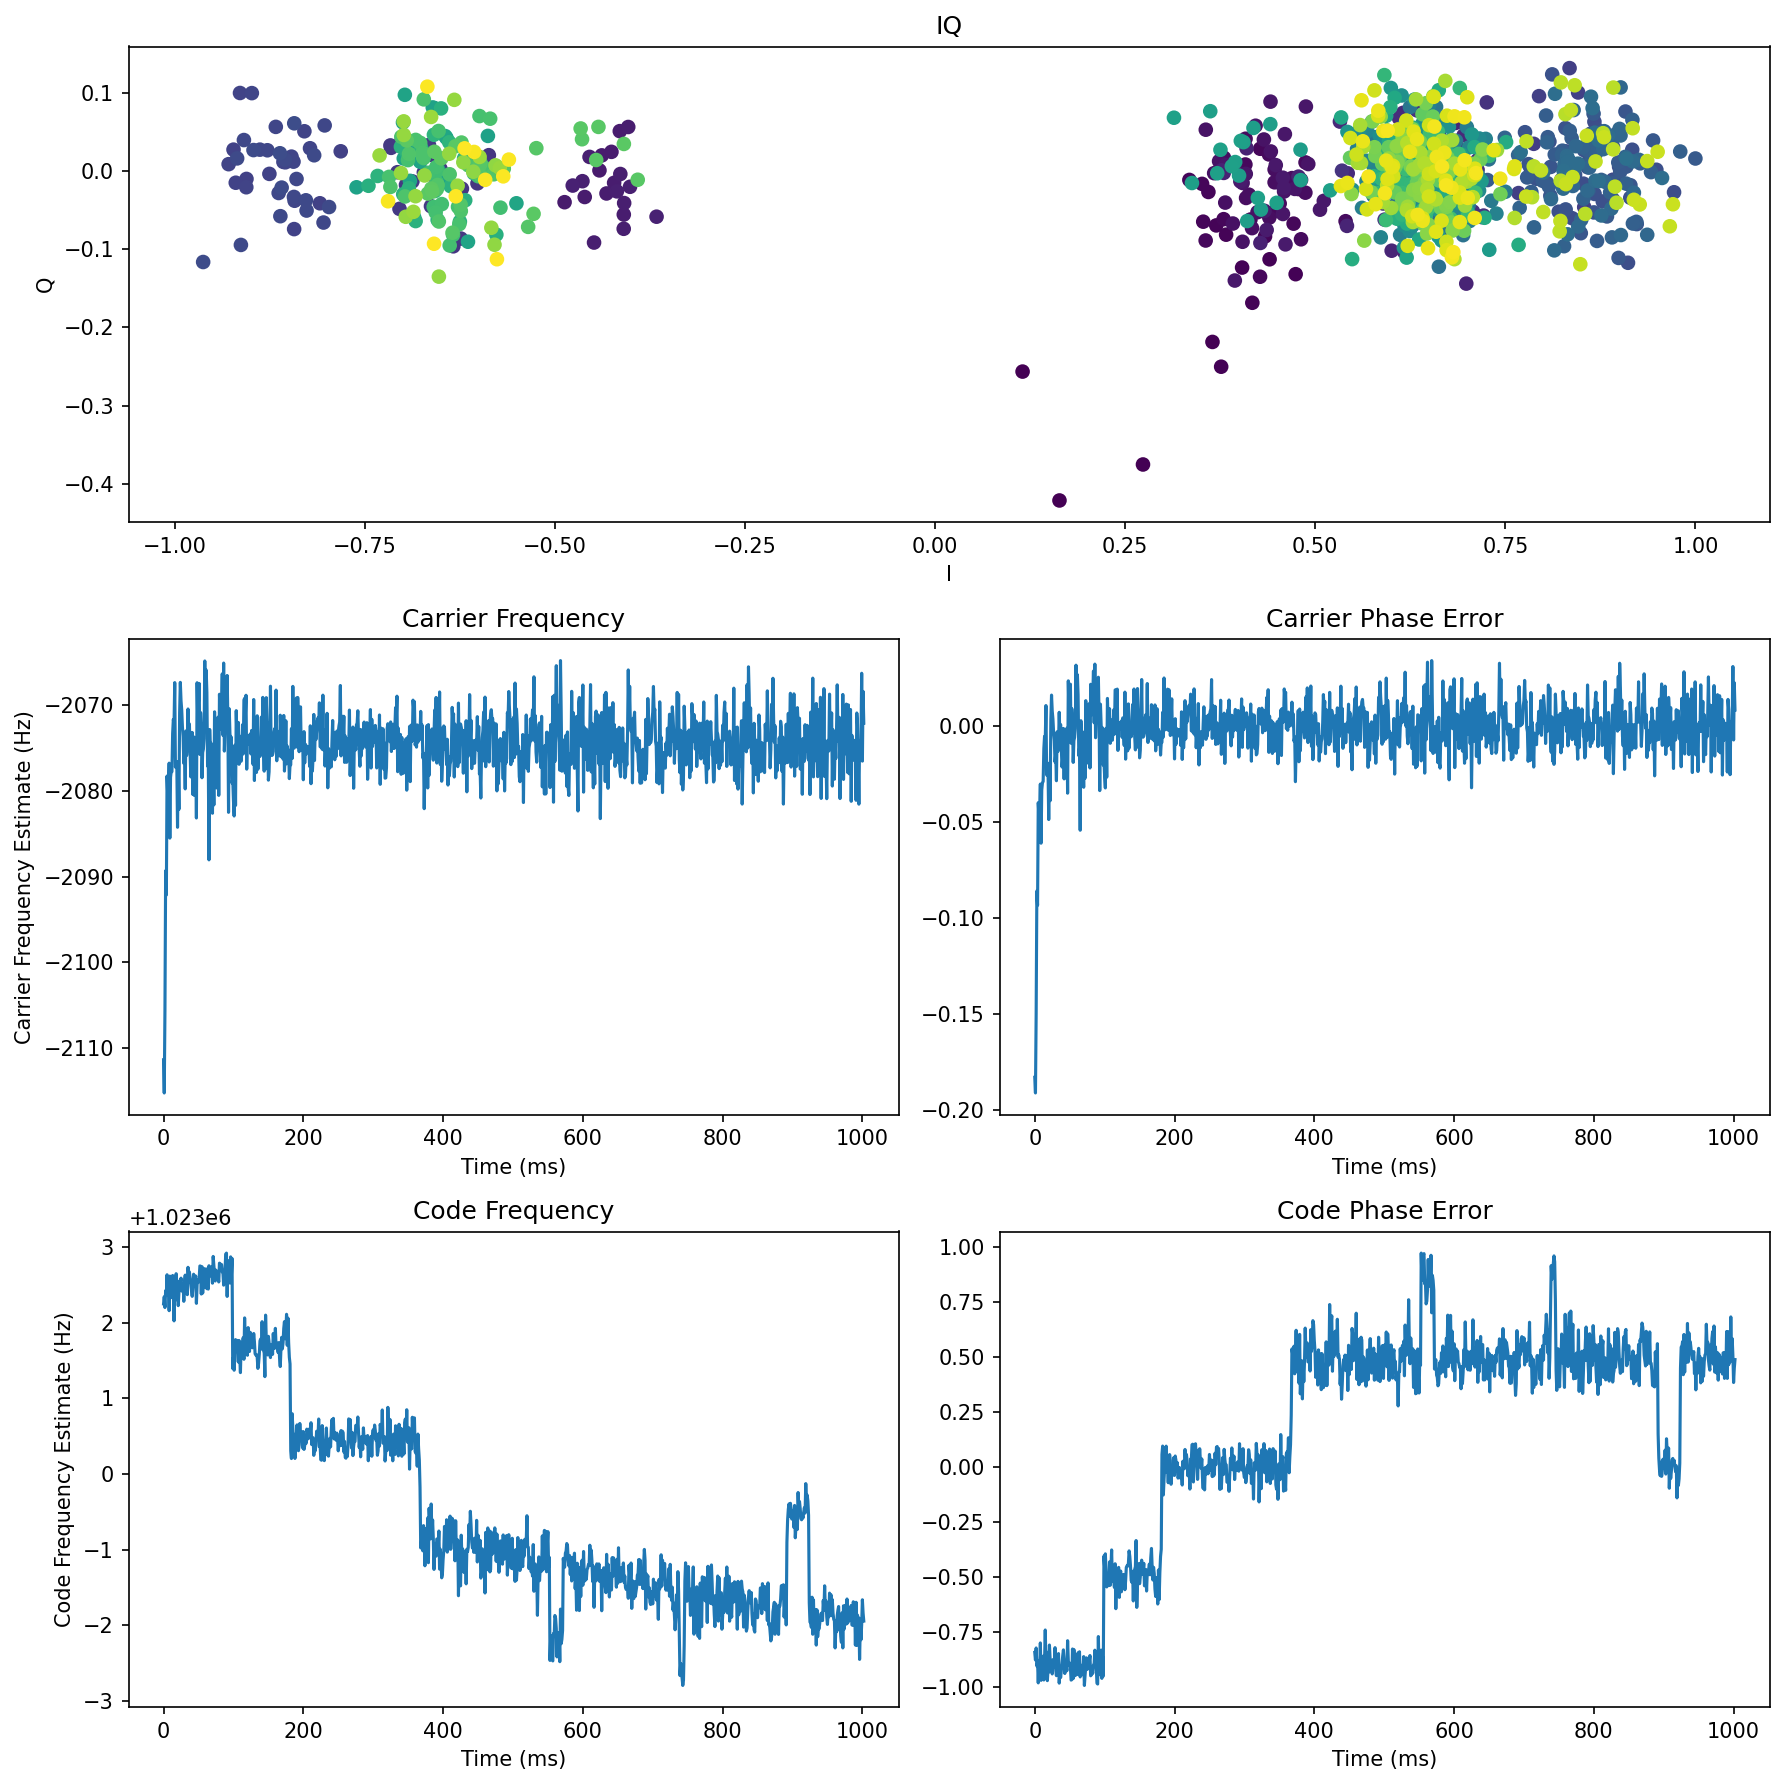

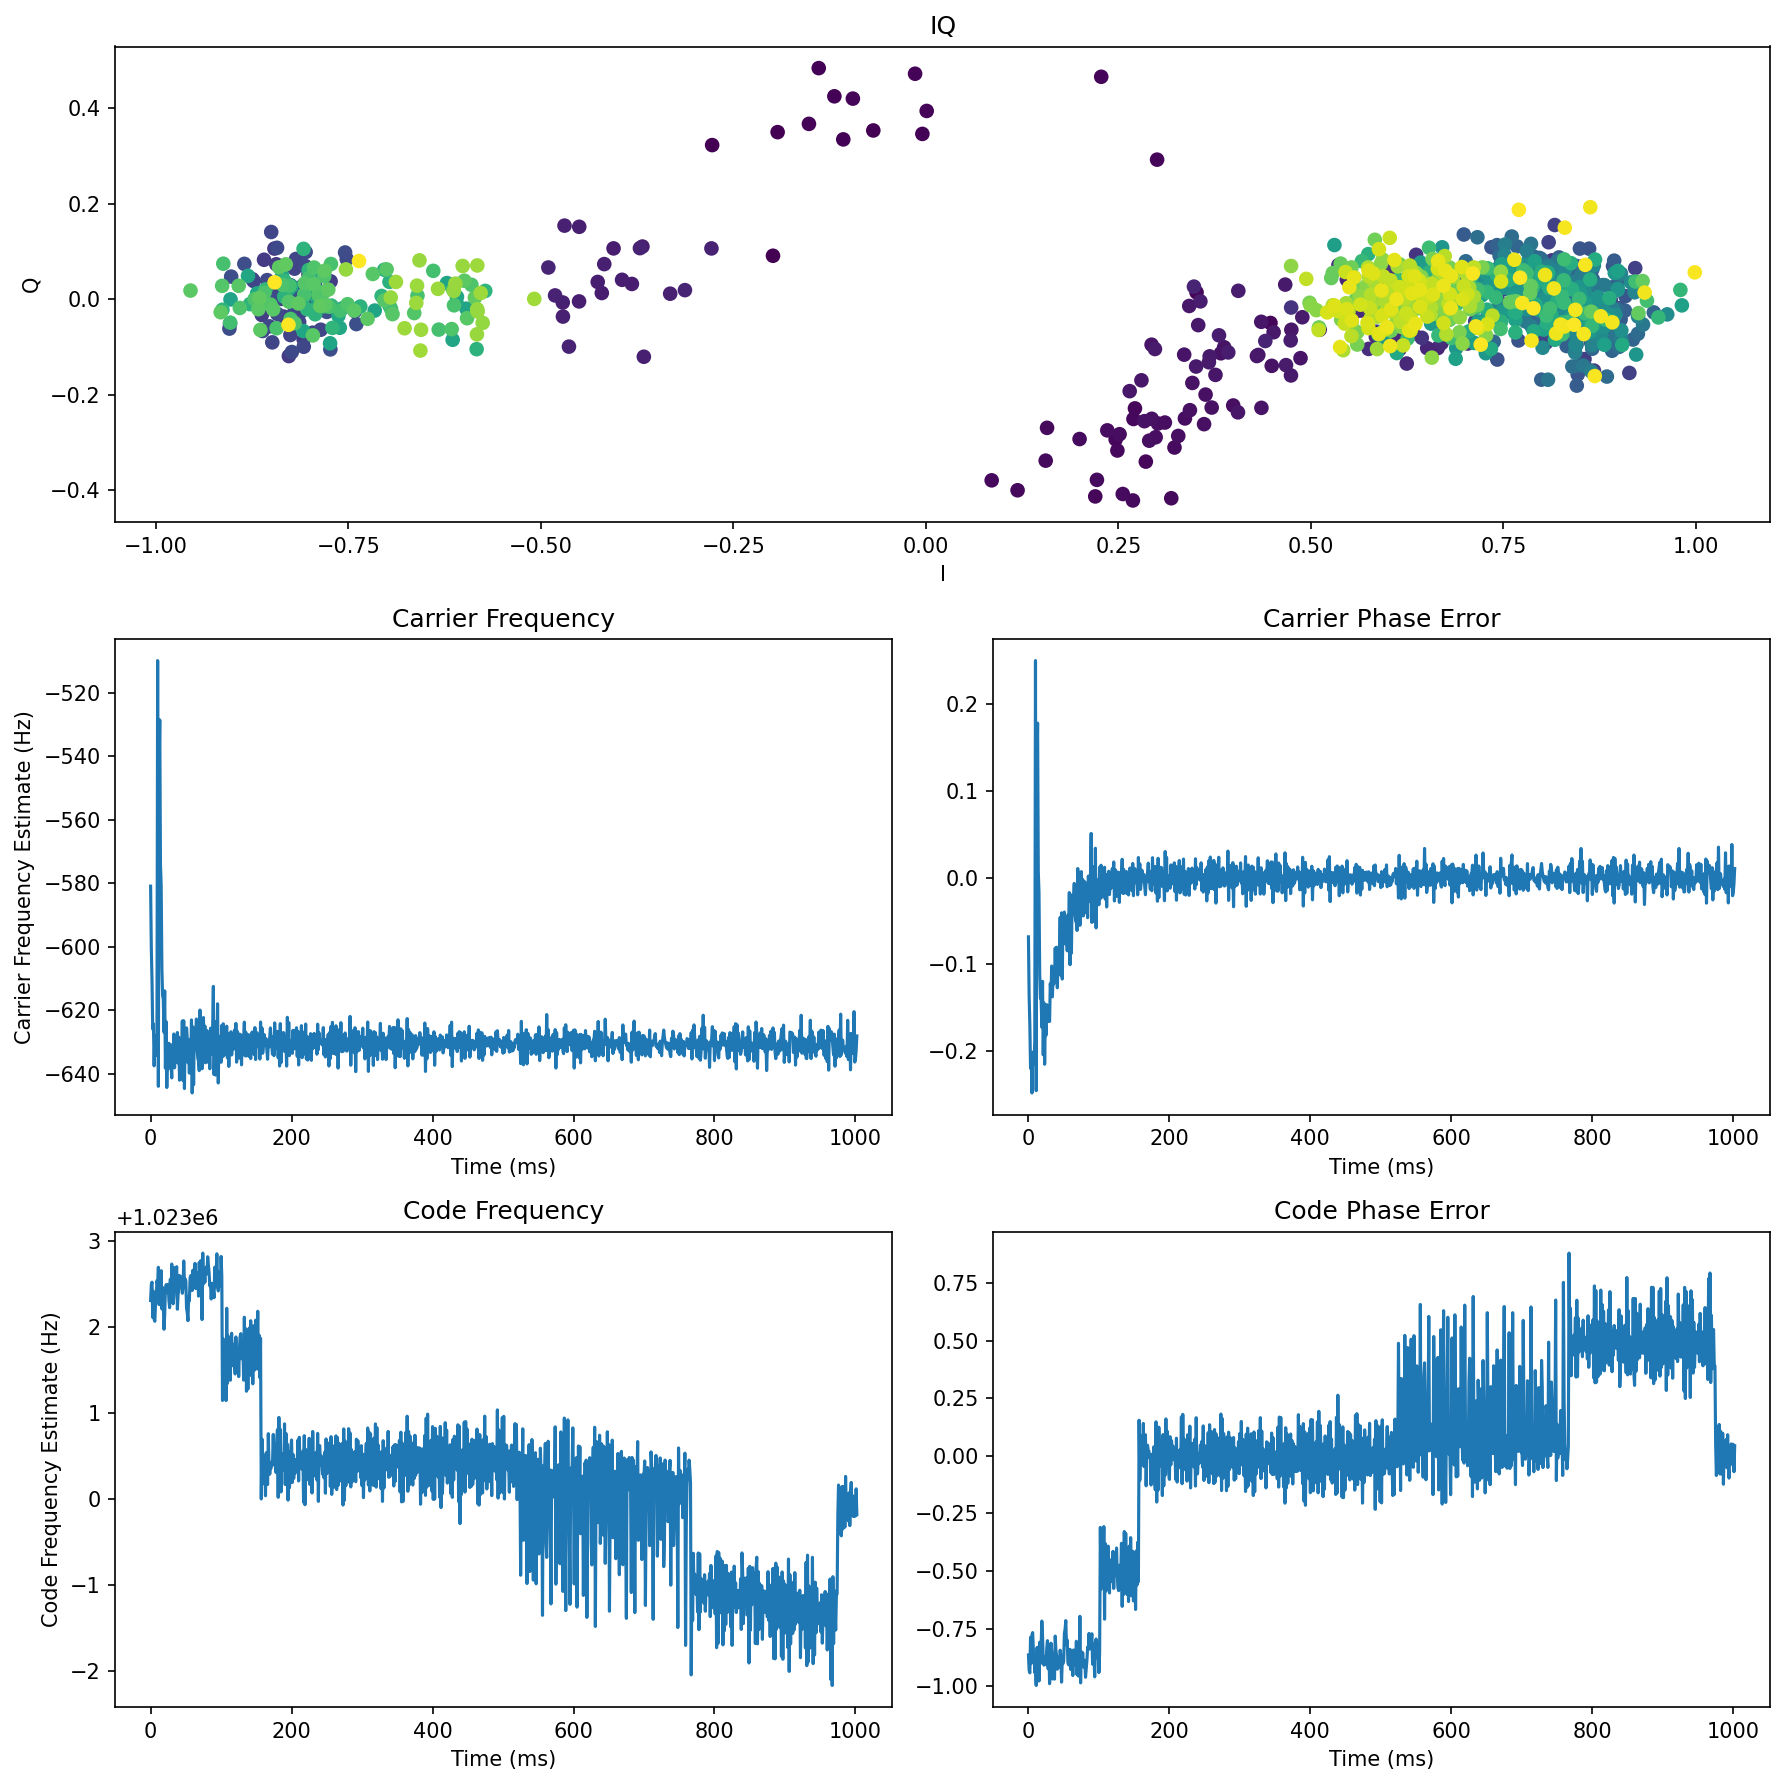

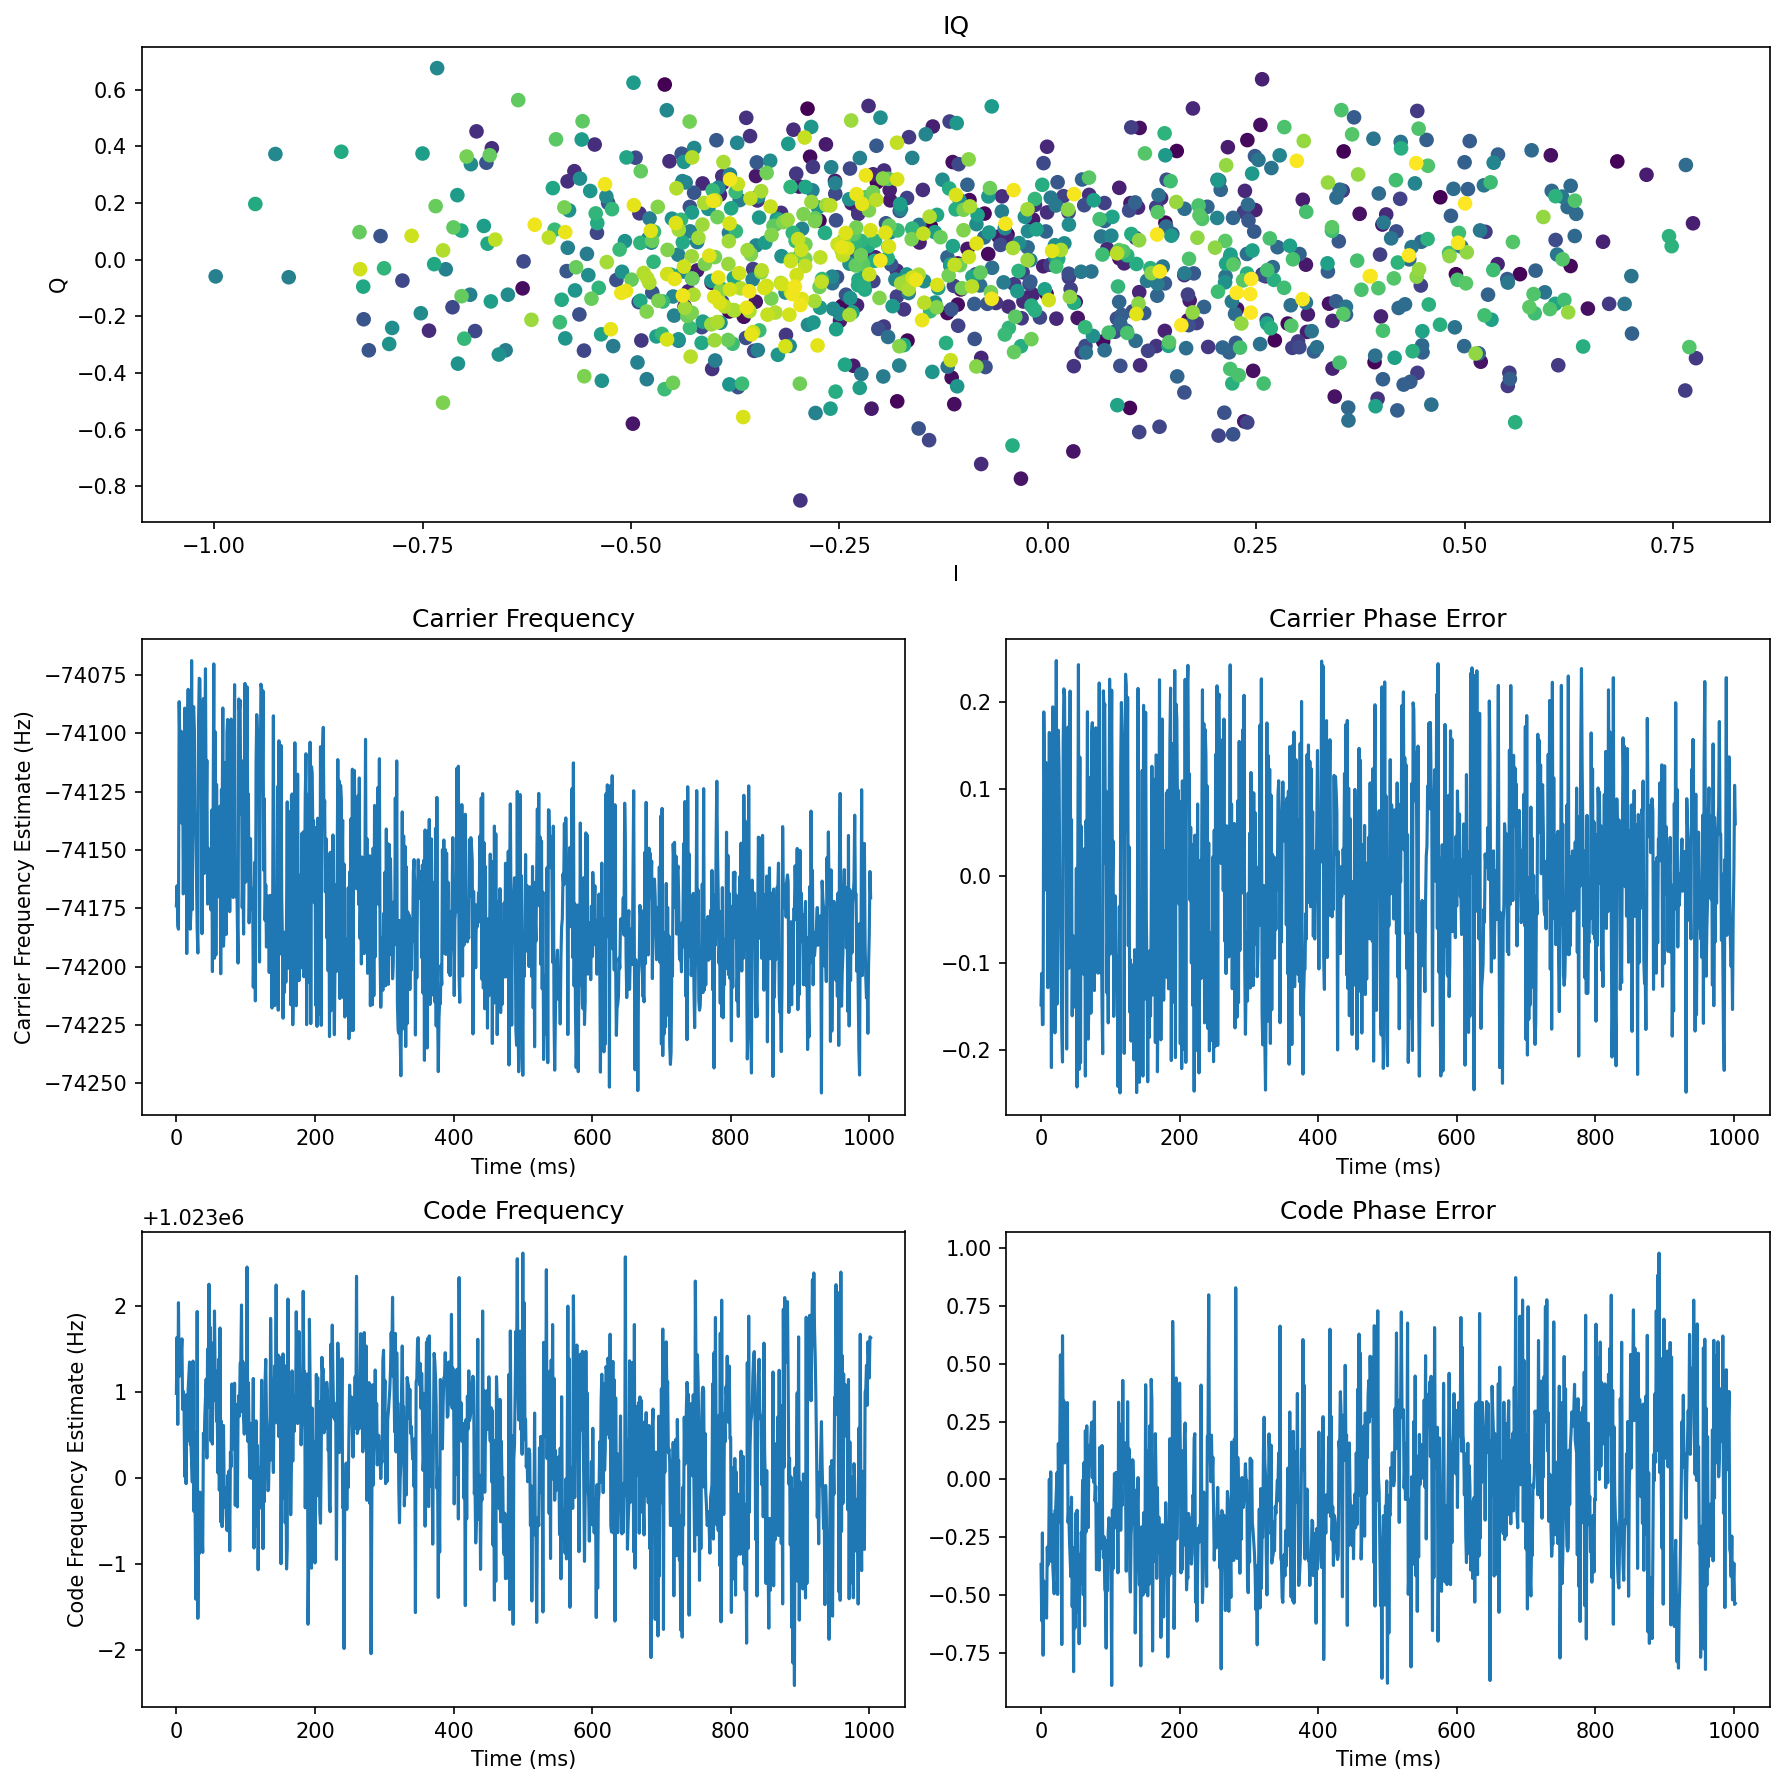

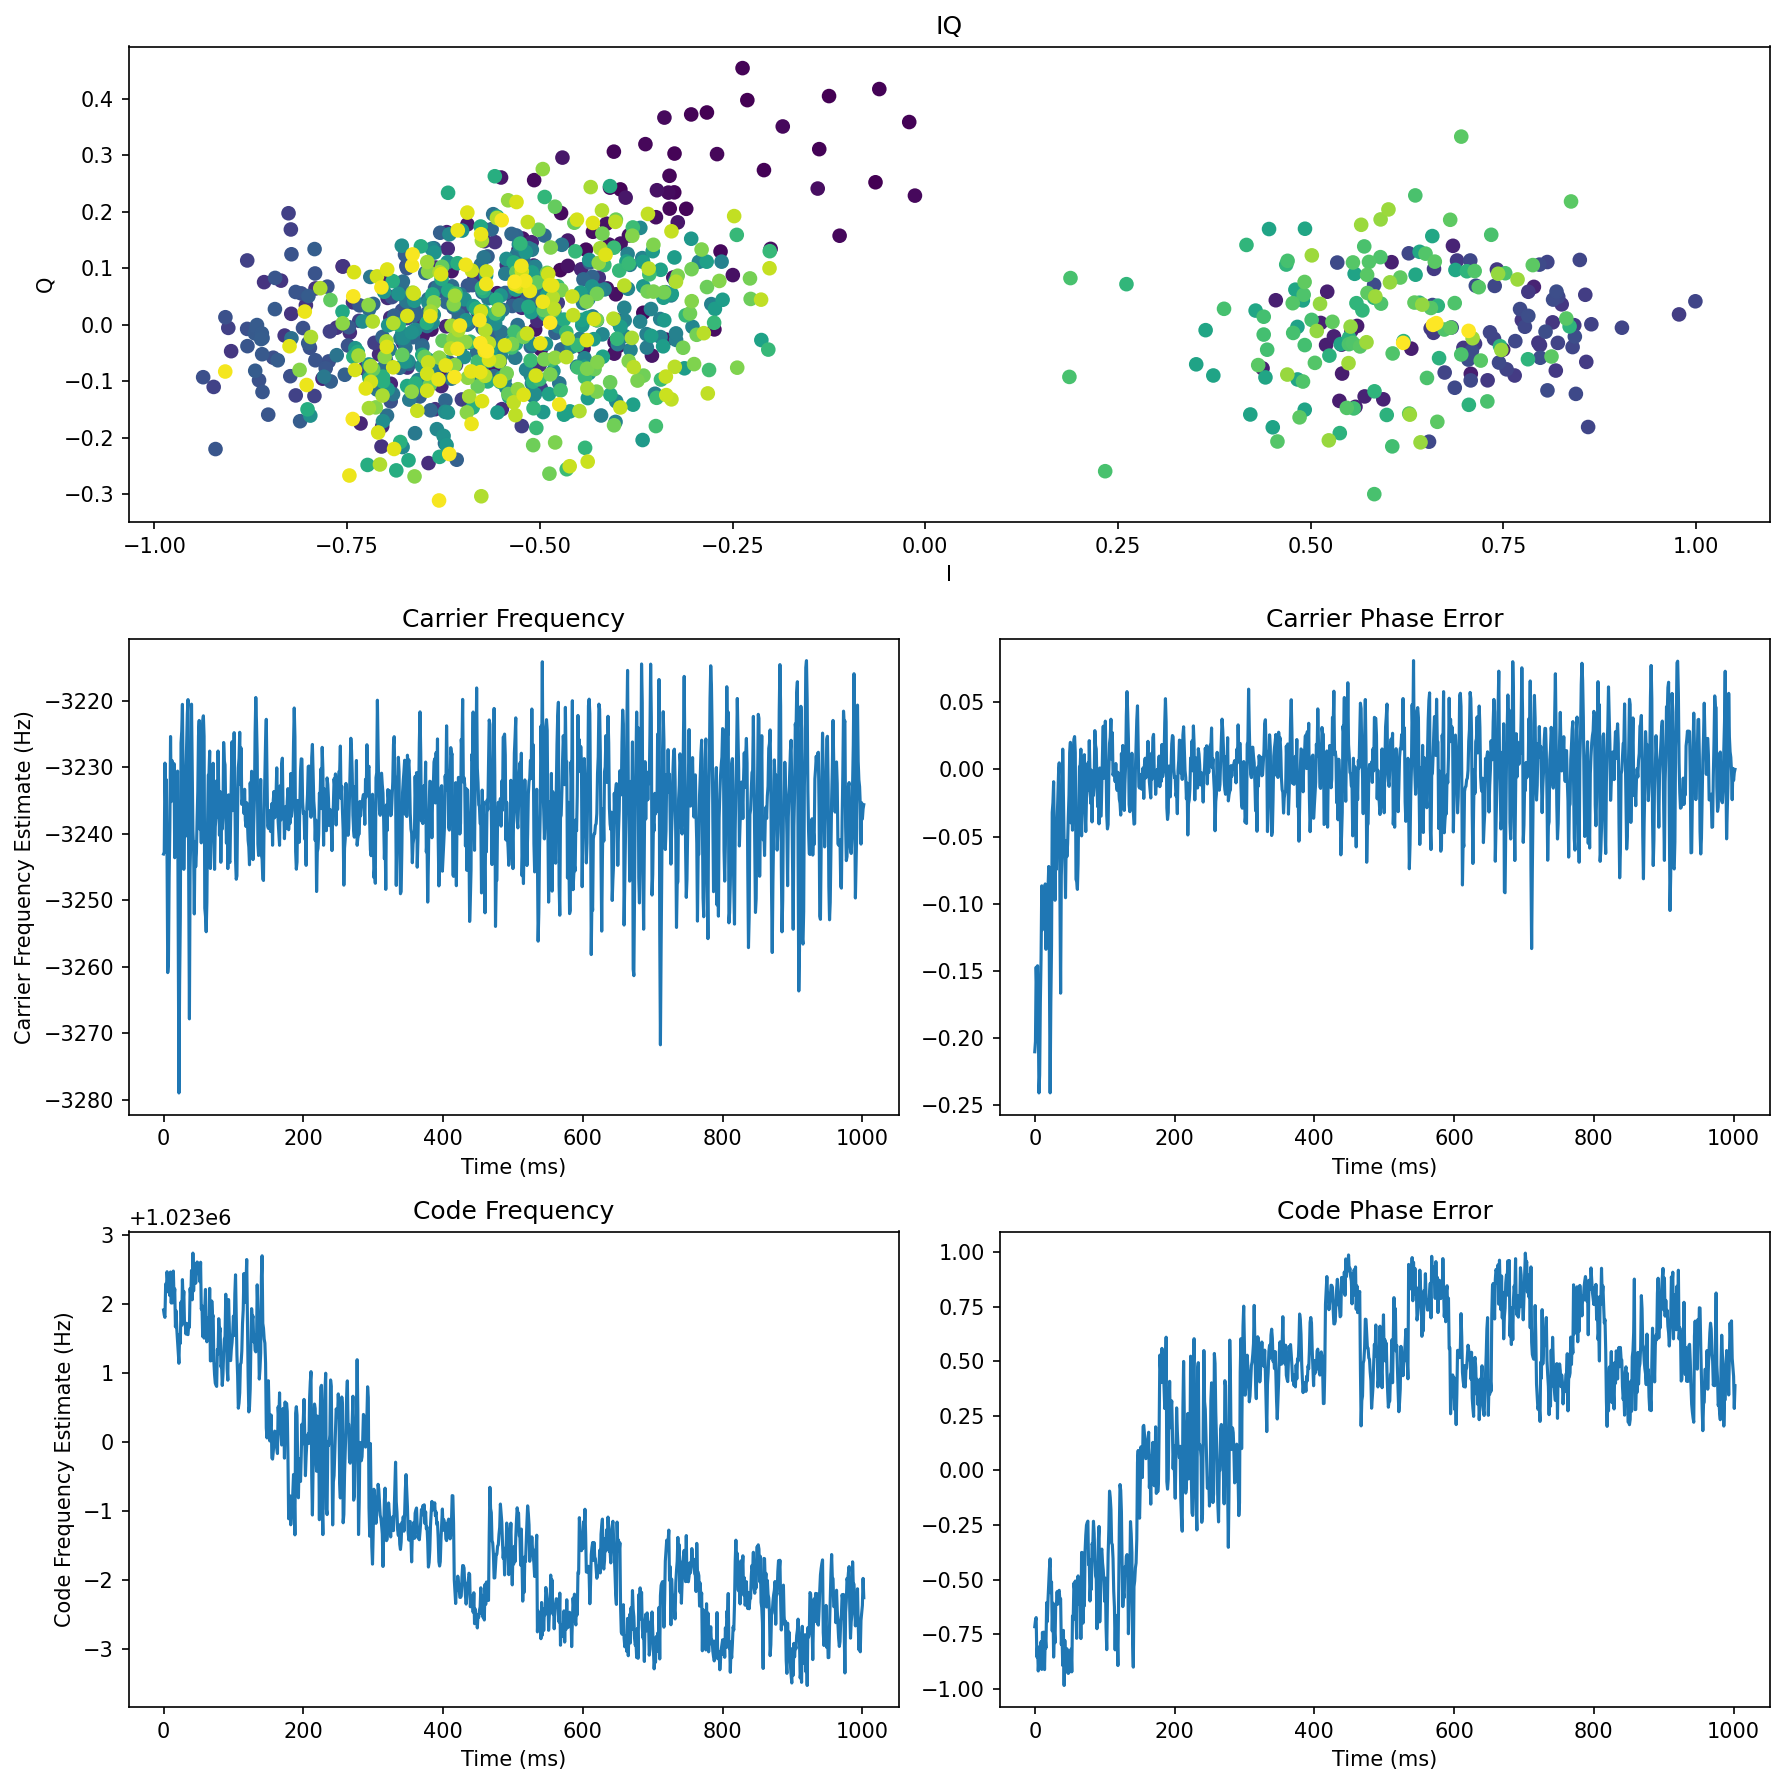

In [4]:
for j in range(np.sum(rx.acquired > 0)):
    iq = rx.out_samples[j]
    iq = np.array(iq, dtype=np.complex64)
    iq = iq / np.max(np.abs(iq))

    debug = rx.channels[j].debug

    # plt.figure()
    # plt.scatter(iq.real, iq.imag, c=np.arange(len(iq)))
    # plt.title(f"SV: {rx.acquired[j]}")

    plt.figure(figsize=(12, 12), dpi=150)

    plt.subplot(3, 2, (1, 2))
    plt.scatter(iq.real, iq.imag, c=np.arange(len(iq)))
    plt.title("IQ")
    plt.xlabel("I")
    plt.ylabel("Q")

    plt.subplot(3, 2, 3)
    plt.plot(debug.carr_freq)
    plt.title("Carrier Frequency")
    plt.xlabel("Time (ms)")
    plt.ylabel("Carrier Frequency Estimate (Hz)")

    plt.subplot(3, 2, 4)
    plt.plot(debug.carr_err)
    plt.title("Carrier Phase Error")
    plt.xlabel("Time (ms)")

    plt.subplot(3, 2, 5)
    plt.plot(debug.code_freq)
    plt.title("Code Frequency")
    plt.xlabel("Time (ms)")
    plt.ylabel("Code Frequency Estimate (Hz)")

    plt.subplot(3, 2, 6)
    plt.plot(debug.code_err)
    plt.title("Code Phase Error")
    plt.xlabel("Time (ms)")

    plt.tight_layout()